# Aggregating Data

In this notebook, we will merge the following data files: 

- VarroaPathogen_quarterly_agg_215on.csv which contains the processed data from APHIS. 
- bee_data_cleaned.csv which contains the processed USDA NASS survey
- fall-2025-bee-health-early-warning-system/data/interim/normalized_weather_adv_data.csv which contains processed weather data from NOAA 



In [28]:
# Load necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import us
import seaborn as sns
import itertools
from itertools import product

Start by loading all the data sets and renaming columns so that they are consistent across data sets. 

## NASS Data Set

In [29]:
nass_df = pd.read_csv("../data/interim/bee_data_cleaned.csv", na_values=["NaN"])

In [30]:
# shorten some column names: 
nass_df = nass_df.rename(columns={
    'Year': 'year', 
    'Period':'quarter', 
    'State': 'state',
    'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN PCT OF COLONIES': 'pct_loss',
    'HONEY, BEE COLONIES, AFFECTED BY DISEASE - INVENTORY, MEASURED IN PCT OF COLONIES': 'pct_disease', 
    'HONEY, BEE COLONIES, AFFECTED BY OTHER CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES': 'pct_other',
    'HONEY, BEE COLONIES, AFFECTED BY PESTICIDES - INVENTORY, MEASURED IN PCT OF COLONIES': 'pct_pesticides',
    'HONEY, BEE COLONIES, AFFECTED BY PESTS ((EXCL VARROA MITES)) - INVENTORY, MEASURED IN PCT OF COLONIES':'pct_pests_nomites',
    'HONEY, BEE COLONIES, AFFECTED BY UNKNOWN CAUSES - INVENTORY, MEASURED IN PCT OF COLONIES':'pct_unknown',
    'HONEY, BEE COLONIES, AFFECTED BY VARROA MITES - INVENTORY, MEASURED IN PCT OF COLONIES':'pct_varroa',
})

In [31]:
# drop columns with colony counts rather than percent (redundant): 
nass_df = nass_df.drop(columns=['HONEY, BEE COLONIES - ADDED & REPLACED, MEASURED IN COLONIES', 
                                'HONEY, BEE COLONIES - INVENTORY, MAX, MEASURED IN COLONIES',
                                'COLONIES AT FIRST OF QUARTER', 
                                'HONEY, BEE COLONIES - LOSS, DEADOUT, MEASURED IN COLONIES', 
                                'HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN COLONIES', 
                                'HONEY, BEE COLONIES, RENOVATED - INVENTORY, MEASURED IN PCT OF COLONIES'], axis=1)

In [32]:
nass_df = nass_df[nass_df['state'] != 'OTHER STATES']

In [33]:
# Map full name to abbreviation
nass_df["state_code"] = nass_df["state"].map(lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else None)

In [34]:
# Remove redundant state information 
nass_df = nass_df.drop(columns = ['state'], axis = 1)

In [35]:
nass_df.sample(5)

,year,quarter,pct_loss,pct_disease,pct_other,pct_pesticides,pct_pests_nomites,pct_unknown,pct_varroa,state_code
74,2015,Q2,8.0,0.3,5.8,3.5,14.3,3.0,51.0,NC
1205,2021,Q4,10.0,4.9,4.0,12.0,8.0,11.2,58.1,ID
824,2019,Q3,22.0,2.5,9.4,4.6,0.9,0.3,47.3,WA
1712,2024,Q3,19.0,7.4,1.8,3.5,34.0,0.6,55.3,WI
579,2018,Q1,14.0,1.4,8.0,1.9,11.9,6.0,25.3,NY


In [36]:
nass_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1735 entries, 0 to 1775
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               1735 non-null   int64  
 1   quarter            1735 non-null   object 
 2   pct_loss           1735 non-null   float64
 3   pct_disease        1735 non-null   float64
 4   pct_other          1735 non-null   float64
 5   pct_pesticides     1735 non-null   float64
 6   pct_pests_nomites  1735 non-null   float64
 7   pct_unknown        1735 non-null   float64
 8   pct_varroa         1735 non-null   float64
 9   state_code         1735 non-null   object 
dtypes: float64(7), int64(1), object(2)
memory usage: 149.1+ KB


In [37]:
# Check that the percent loss column is fully populated
nass_df['pct_loss'].isna().any()

np.False_

In [38]:
# Notice the NASS data has no data for Alaska 
print(nass_df[nass_df['state_code'] == 'AK'])

Empty DataFrame
Columns: [year, quarter, pct_loss, pct_disease, pct_other, pct_pesticides, pct_pests_nomites, pct_unknown, pct_varroa, state_code]
Index: []


## APHIS Data Set

In [39]:
# Load APHIS data
aphis_df = pd.read_csv('../data/interim/pathogen_data_quarterly_aggregated.csv')
aphis_df.sample(5)


,sample_year,sample_quarter,state_code,mean_varroa_q,mean_spores_q,abpv_prevalence_q,cbpv_prevalence_q,dwv_prevalence_q,iapv_prevalence_q,kbv_prevalence_q,...,last_month_mean_varroa,last_month_mean_spores,last_month_abpv_prevalence,last_month_cbpv_prevalence,last_month_dwv_prevalence,last_month_iapv_prevalence,last_month_kbv_prevalence,last_month_lsv2_prevalence,unique_counties_sampled_q,last_month_in_quarter
398,2019,Q1,HI,1.348750,1.056250,0.250000,0.000000,0.375000,0.125000,0.000000,...,1.34875,1.05625,0.250000,0.0,0.375,0.125000,0.000000,0.000000,3,3
746,2022,Q3,MI,0.550000,0.278571,0.142857,0.000000,0.714286,0.428571,0.000000,...,0.86800,0.09000,0.400000,0.0,0.800,0.400000,0.000000,0.000000,12,9
145,2016,Q3,NM,1.542308,0.076923,0.076923,0.076923,1.000000,0.153846,0.000000,...,1.29000,0.00000,0.000000,0.0,1.000,0.166667,0.000000,0.166667,8,9
28,2015,Q2,VT,5.435000,0.775000,0.000000,0.500000,1.000000,0.000000,0.000000,...,5.43500,0.77500,0.000000,0.5,1.000,0.000000,0.000000,1.000000,2,6
165,2016,Q4,IA,2.162500,0.812500,0.666667,0.000000,1.000000,0.666667,0.666667,...,2.16250,0.81250,0.666667,0.0,1.000,0.666667,0.666667,0.666667,4,10


In [40]:
# rename a few columns for consistency
aphis_df = aphis_df.rename(columns={
    'sample_year':'year', 
    'sample_quarter': 'quarter'}
)

In [41]:
print(aphis_df[aphis_df['state_code'] == 'AK'])

     year quarter state_code  mean_varroa_q  mean_spores_q  abpv_prevalence_q  \
331  2018      Q3         AK       1.176000       0.700000                0.0   
401  2019      Q2         AK       0.654000       0.320000                0.0   
432  2019      Q3         AK       2.000000       0.000000                0.0   
500  2020      Q2         AK       0.027500       1.537500                0.0   
523  2020      Q3         AK       1.605000       0.158333                0.0   
587  2021      Q2         AK       0.430000       1.250000                0.0   
619  2021      Q3         AK       2.854286       0.050000                0.0   
685  2022      Q1         AK       0.170000       1.100000                NaN   
696  2022      Q2         AK       0.000000      24.050000                1.0   
832  2023      Q3         AK       0.520417       0.758333                0.0   
937  2024      Q3         AK       2.600000       0.160000                0.0   

     cbpv_prevalence_q  dwv

In [42]:
print(aphis_df['state_code'].unique())

['CA' 'FL' 'GU' 'HI' 'TX' 'UT' 'AL' 'AR' 'CT' 'IA' 'ID' 'IN' 'MI' 'MN'
 'MT' 'NJ' 'NY' 'PA' 'PR' 'SC' 'SD' 'TN' 'VA' 'VT' 'WI' 'GA' 'IL' 'KY'
 'NC' 'ND' 'NM' 'OH' 'WV' 'MD' 'MS' 'OR' 'CO' 'DE' 'LA' 'NE' 'WA' 'MA'
 'NV' 'KS' 'MO' 'DC' 'ME' 'OK' 'AK' 'CNMI' 'RI' 'WY']


In [43]:
# drop all AK data. There is no data in NASS or the weather data for AK. Also drop GU and PR since we do not have collapse data for territories 
aphis_df = aphis_df[aphis_df['state_code'] != 'AK']
aphis_df = aphis_df[aphis_df['state_code'] != 'GU']
aphis_df = aphis_df[aphis_df['state_code'] != 'PR']
aphis_df = aphis_df[aphis_df['state_code'] != 'CNMI']
aphis_df = aphis_df[aphis_df['state_code'] != 'DC']



In [44]:
aphis_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 932 entries, 0 to 993
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   year                         932 non-null    int64  
 1   quarter                      932 non-null    object 
 2   state_code                   932 non-null    object 
 3   mean_varroa_q                926 non-null    float64
 4   mean_spores_q                926 non-null    float64
 5   abpv_prevalence_q            929 non-null    float64
 6   cbpv_prevalence_q            929 non-null    float64
 7   dwv_prevalence_q             929 non-null    float64
 8   iapv_prevalence_q            929 non-null    float64
 9   kbv_prevalence_q             929 non-null    float64
 10  lsv2_prevalence_q            929 non-null    float64
 11  varroa_total_samples_q       932 non-null    int64  
 12  spores_total_samples_q       932 non-null    int64  
 13  abpv_total_samples_q     

In [45]:
# Include a column for the region associated with each state. 
state_to_region = {
    "AL": "Southeast",
    "AK": "Alaska", # does not align climactically with any other region. Note: NASS has no data for Alaska, APHIS for 2018 onward, so was dropped    "AZ": "Southwest",
    "AR": "South",
    "CA": "West",
    "CO": "Southwest",
    "CT": "Northeast",
    "DE": "Northeast",
    "FL": "Southeast",
    "GA": "Southeast",
    "HI": "West", # choice made because of: oceanic influence, mild temperatures, winter wet season, and dry summer months.
    "ID": "Northwest",
    "IL": "Ohio Valley",
    "IN": "Ohio Valley",
    "IA": "Upper Midwest",
    "KS": "South",
    "KY": "Ohio Valley",
    "LA": "South",
    "ME": "Northeast",
    "MD": "Northeast",
    "MA": "Northeast",
    "MI": "Upper Midwest",
    "MN": "Upper Midwest",
    "MS": "Southeast",
    "MO": "South",
    "MT": "Northern Rockies & Plains",
    "NE": "Northern Rockies & Plains",
    "NV": "Southwest",
    "NH": "Northeast",
    "NJ": "Northeast",
    "NM": "Southwest",
    "NY": "Northeast",
    "NC": "Southeast",
    "ND": "Northern Rockies & Plains",
    "OH": "Ohio Valley",
    "OK": "South",
    "OR": "Northwest",
    "PA": "Northeast",
    "RI": "Northeast",
    "SC": "Southeast",
    "SD": "Northern Rockies & Plains",
    "TN": "Southeast",
    "TX": "South",
    "UT": "Southwest",
    "VT": "Northeast",
    "VA": "Southeast",
    "WA": "Northwest",
    "WV": "Ohio Valley",
    "WI": "Upper Midwest",
    "WY": "Northern Rockies & Plains"
}


In [46]:
aphis_df['region']=aphis_df['state_code'].map(state_to_region)
nass_df['region']=nass_df['state_code'].map(state_to_region)

## Weather Data Set

In [47]:
# Load weather data
weather_df = pd.read_csv("../data/interim/normalized_weather_adv_data.csv", na_values=["NaN"])

In [48]:
weather_df.sample(5)

,state_id,state_name,Year,Quarter,M1_avg_prcp,M2_avg_prcp,M3_avg_prcp,M1_max_prcp,M2_max_prcp,M3_max_prcp,...,Q_tmin_avg,Num_Frost_Days,M1_avg_tvol,M2_avg_tvol,M3_avg_tvol,M1_max_tvol,M2_max_tvol,M3_max_tvol,Q_tvol_avg,Num_high_vol_days
638,14,Kansas,2020,Q4,0.089298,0.083450,0.056601,0.134503,0.182533,0.083244,...,0.448894,0.569892,0.646486,0.786625,0.716503,0.131242,0.411415,0.298552,0.633771,0.400000
2287,49,Hawaii,2021,Q4,0.400882,0.171096,0.903451,0.179970,0.083447,0.483503,...,0.862178,0.000000,0.190176,0.425370,0.346821,0.312224,0.396354,0.296999,0.047827,0.000000
1989,43,Vermont,2017,Q4,0.432194,0.140912,0.190271,0.300903,0.105341,0.123223,...,0.355553,0.634409,0.521893,0.499485,0.466549,0.224712,0.287753,0.318456,0.292881,0.028571
2071,45,Washington,2014,Q4,0.493709,0.391590,0.381941,0.219053,0.228003,0.193625,...,0.468233,0.365591,0.317226,0.408449,0.313550,0.218950,0.281807,0.203860,0.075110,0.000000
757,17,Maine,2015,Q2,0.261650,0.173822,0.367137,0.148764,0.116275,0.175738,...,0.540662,0.268817,0.448149,0.716299,0.581281,0.311780,0.387634,0.265380,0.442762,0.071429


In [49]:
# rename some columns for consistency
weather_df = weather_df.rename(columns={
    'Year': 'year', 
    'Quarter': 'quarter'}
)

In [50]:
# Map full name to abbreviation
weather_df["state_code"] = weather_df["state_name"].map(lambda x: us.states.lookup(x).abbr if us.states.lookup(x) else None)


In [51]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2304 entries, 0 to 2303
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   state_id               2304 non-null   int64  
 1   state_name             2304 non-null   object 
 2   year                   2304 non-null   int64  
 3   quarter                2304 non-null   object 
 4   M1_avg_prcp            2304 non-null   float64
 5   M2_avg_prcp            2304 non-null   float64
 6   M3_avg_prcp            2304 non-null   float64
 7   M1_max_prcp            2304 non-null   float64
 8   M2_max_prcp            2304 non-null   float64
 9   M3_max_prcp            2304 non-null   float64
 10  Q_prcp_avg             2304 non-null   float64
 11  Consecutive_Rain_Days  2304 non-null   float64
 12  M1_avg_tmax            2304 non-null   float64
 13  M2_avg_tmax            2304 non-null   float64
 14  M3_avg_tmax            2304 non-null   float64
 15  M1_m

In [52]:
weather_df = weather_df.drop(columns=['state_id', 'state_name'], axis=1)

In [55]:
states = [state.abbr for state in us.states.STATES]
states = [s for s in states if s != "AK"]
years = range(2015, 2026)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Create a complete list of all possible months, years, and quarters
expected = pd.DataFrame(product(states, years, quarters),
                        columns=['state_code', 'year', 'quarter'])
# Limit to 2025 Q2
expected = expected[~((expected['year'] == 2025) & (expected['quarter'].isin(['Q3','Q4'])))]

# Merge with existing data  
merged = expected.merge(weather_df[['state_code', 'year', 'quarter','M1_avg_prcp']], on=['state_code', 'year', 'quarter'], how='left')

# Count how many are missing
missing_weather_summary = merged.isna().groupby(merged['year']).mean()


missing_weather_summary.shape

missing_weather_summary.head(50)
# plt.figure(figsize=(10, 6))
# sns.heatmap(missing_weather_summary, cmap='plasma')
# plt.title('Proportion of Missing Weather Data by State and Column')
# plt.show()

,state_code,year,quarter,M1_avg_prcp
year,,,,
2015,0.0,0.0,0.0,0.0
2016,0.0,0.0,0.0,0.0
2017,0.0,0.0,0.0,0.0
2018,0.0,0.0,0.0,0.0
2019,0.0,0.0,0.0,0.0
2020,0.0,0.0,0.0,0.0
2021,0.0,0.0,0.0,0.0
2022,0.0,0.0,0.0,0.0
2023,0.0,0.0,0.0,0.0


The weather dats has no missing states/quarters/years. 

## Combining Data

Since the APHIS and NASS data do not perfectly align (i.e. there are some state/quarter/years in one and not the other), we will have to think carefully about how best to merge the data. We'll investigate four options: 

1. Keep only the state/quarter/years that are represented in both the NASS and APHIS data. (This is an inner merge and will be called bee_complete_df.) 
2. Begin with the state/quarter/years represented in the NASS data and fill in corresponding APHIS data, leaving NaNs for missing data. (This is a left merge and will be called bee_nass_df.) 
3. Begin with the state/quarter/years represented in the APHIS data and fill in the corresponding NASS data, leaving NaNs for missing data. (This is a right merge and will be called bee_aphis_df.) 
4. Keep all state/quarter/years represented in either the NASS or APHIS data sets, filling in NaNs for all missing data. (This is an outer merge and will be called bee_all_df.)  

The next section performs these merges and visualizes the missing data. 

### Investigate the Overlap of the NASS and APHIS data sets 

In [56]:
nass_aphis_both_df = pd.merge(
    nass_df,
    aphis_df,
    on=['year', 'quarter', 'state_code', 'region'],
    how='inner'
)

bee_complete_df = pd.merge(
    nass_aphis_both_df,
    weather_df,
    on=['year', 'quarter', 'state_code'],
    how='left'
)

bee_complete_df.shape

(828, 77)

In [57]:
nass_aphis_left_df = pd.merge(
    nass_df,
    aphis_df,
    on=['year', 'quarter', 'state_code', 'region'],
    how='left'
)

bee_nass_df = pd.merge(
    nass_aphis_left_df,
    weather_df,
    on=['year', 'quarter', 'state_code'],
    how='left'
)

bee_nass_df.shape

(1735, 77)

In [58]:
nass_aphis_right_df = pd.merge(
    nass_df,
    aphis_df,
    on=['year', 'quarter', 'state_code', 'region'],
    how='right'
)

bee_aphis_df = pd.merge(
    nass_aphis_right_df,
    weather_df,
    on=['year', 'quarter', 'state_code'],
    how='left'
)

bee_aphis_df.shape

(932, 77)

In [59]:
nass_aphis_all_df = pd.merge(
    nass_df,
    aphis_df,
    on=['year', 'quarter', 'state_code', 'region'],
    how='outer'
)

bee_all_df = pd.merge(
    nass_aphis_all_df,
    weather_df,
    on=['year', 'quarter', 'state_code'],
    how='left'
)

bee_all_df.shape

(1839, 77)

In [60]:
states = [state.abbr for state in us.states.STATES]
states = [s for s in states if s != "AK"]
years = range(2015, 2025)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

from itertools import product

expected = pd.DataFrame(product(states, years, quarters),
                        columns=['state_code', 'year', 'quarter'])


def visualize_missing(df, expected, name='DataFrame'):
    """
    Visualize missing data grouped by state_code, year, and quarter.
    """
    merged = expected.merge(df[['state_code', 'year', 'quarter', 'region', 'pct_loss','M1_avg_prcp','mean_varroa_q']], on=['state_code', 'year', 'quarter'], how='left')

    # Compute missing summaries
    missing_state = merged[['pct_loss','M1_avg_prcp','mean_varroa_q']].isna().groupby(merged['state_code']).mean()
    missing_region = merged[['pct_loss','M1_avg_prcp','mean_varroa_q']].isna().groupby(merged['region']).mean()
    missing_year = merged[['pct_loss','M1_avg_prcp','mean_varroa_q']].isna().groupby(merged['year']).mean()
    missing_quarter = merged[['pct_loss','M1_avg_prcp','mean_varroa_q']].isna().groupby(merged['quarter']).mean()

    # Shared color scale
    all_missing = pd.concat([missing_state, missing_year, missing_quarter])
    vmin, vmax = all_missing.min().min(), all_missing.max().max()



    # Plot
    fig, axes = plt.subplots(1,4, figsize=(18, 6))
    sns.heatmap(missing_state, ax=axes[0], cmap='plasma', cbar=False, vmin=vmin, vmax=vmax,)
    axes[0].set_title(f'{name}: Missing Data by State')

    sns.heatmap(missing_region, ax=axes[1], cmap='plasma', cbar=False, vmin=vmin, vmax=vmax,)
    axes[1].set_title(f'{name}: Missing Data by Region')
    
    sns.heatmap(missing_year, ax=axes[2], cmap='plasma', cbar=False, vmin=vmin, vmax=vmax,)
    axes[2].set_title(f'{name}: Missing Data by Year')
    
    sns.heatmap(missing_quarter, ax=axes[3], cmap='plasma', cbar=True, vmin=vmin, vmax=vmax,)
    axes[3].set_title(f'{name}:  Missing Data by Quarter')
    
    plt.tight_layout()
    plt.show()

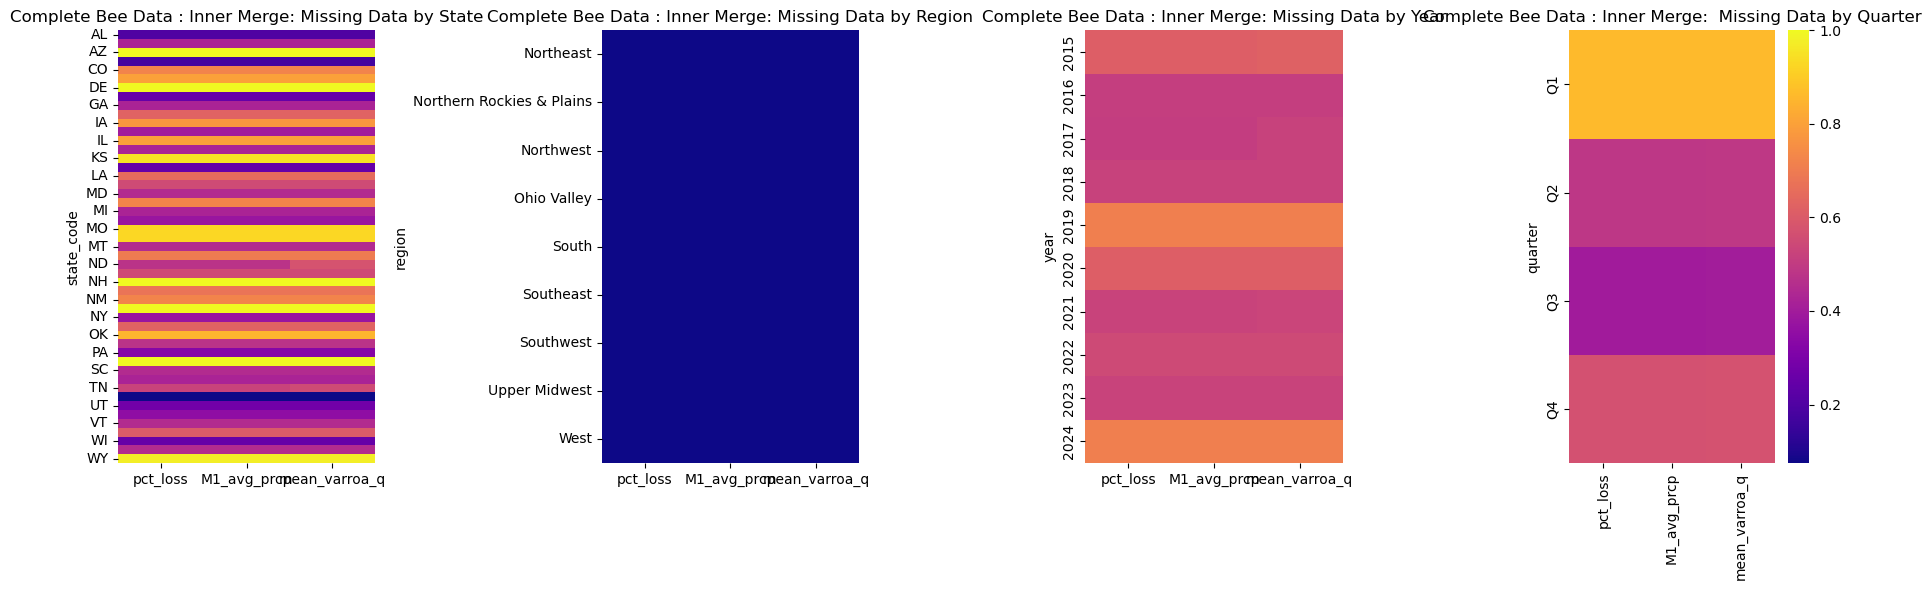

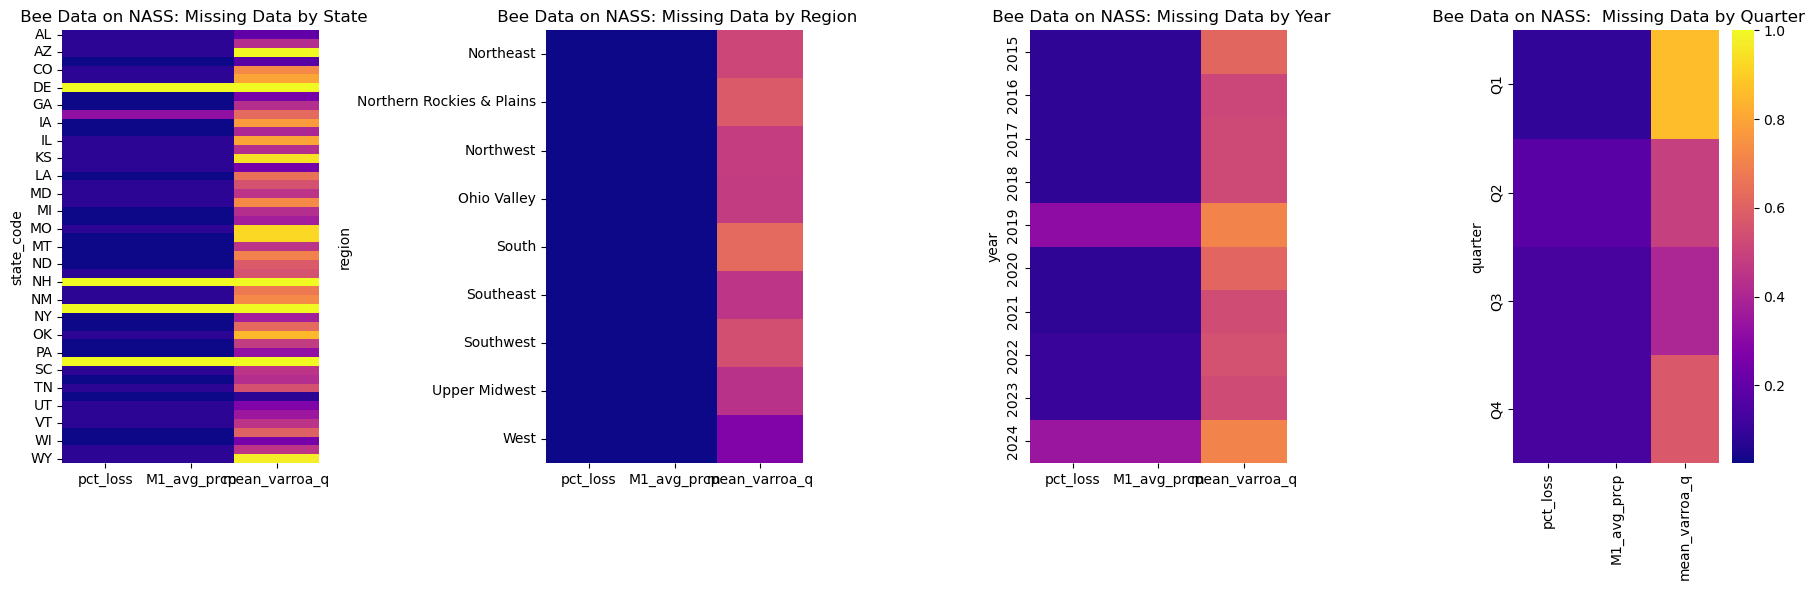

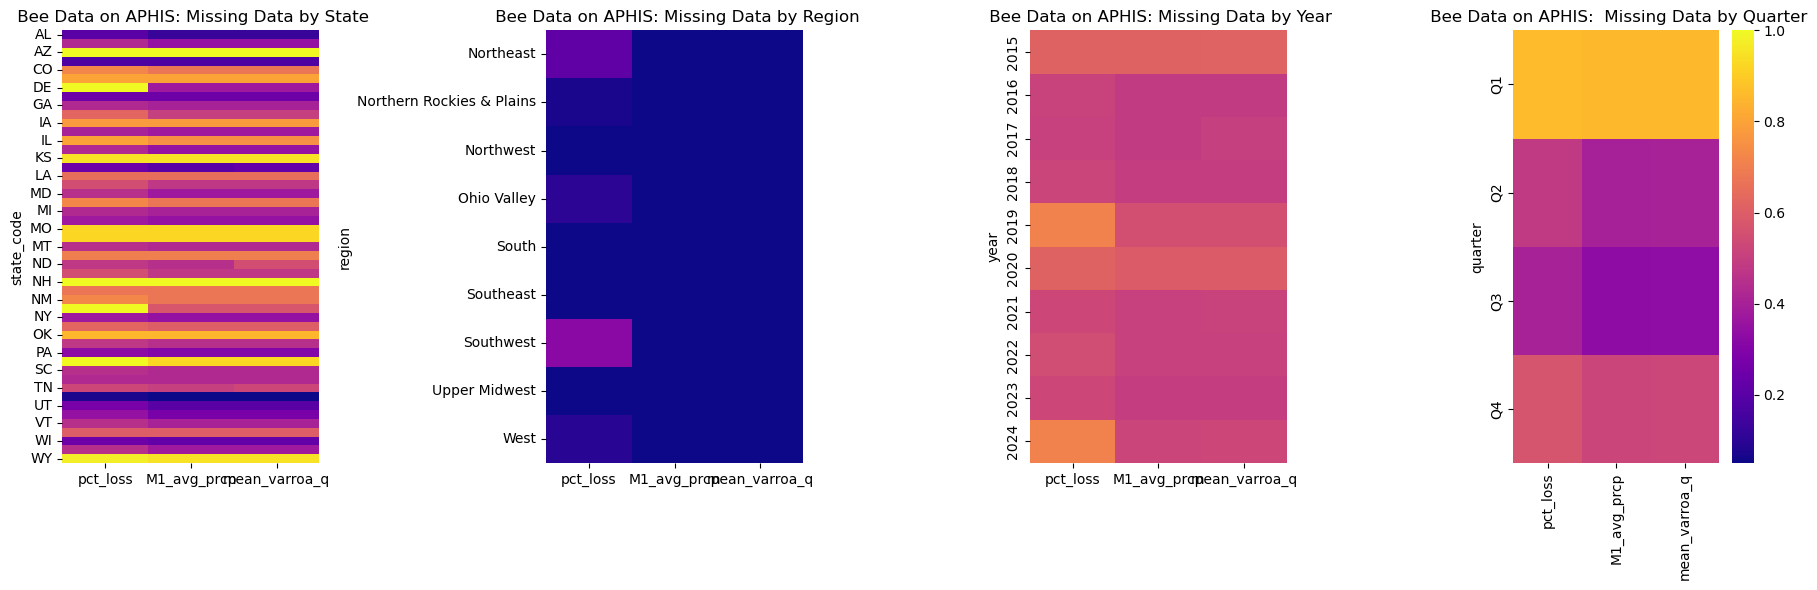

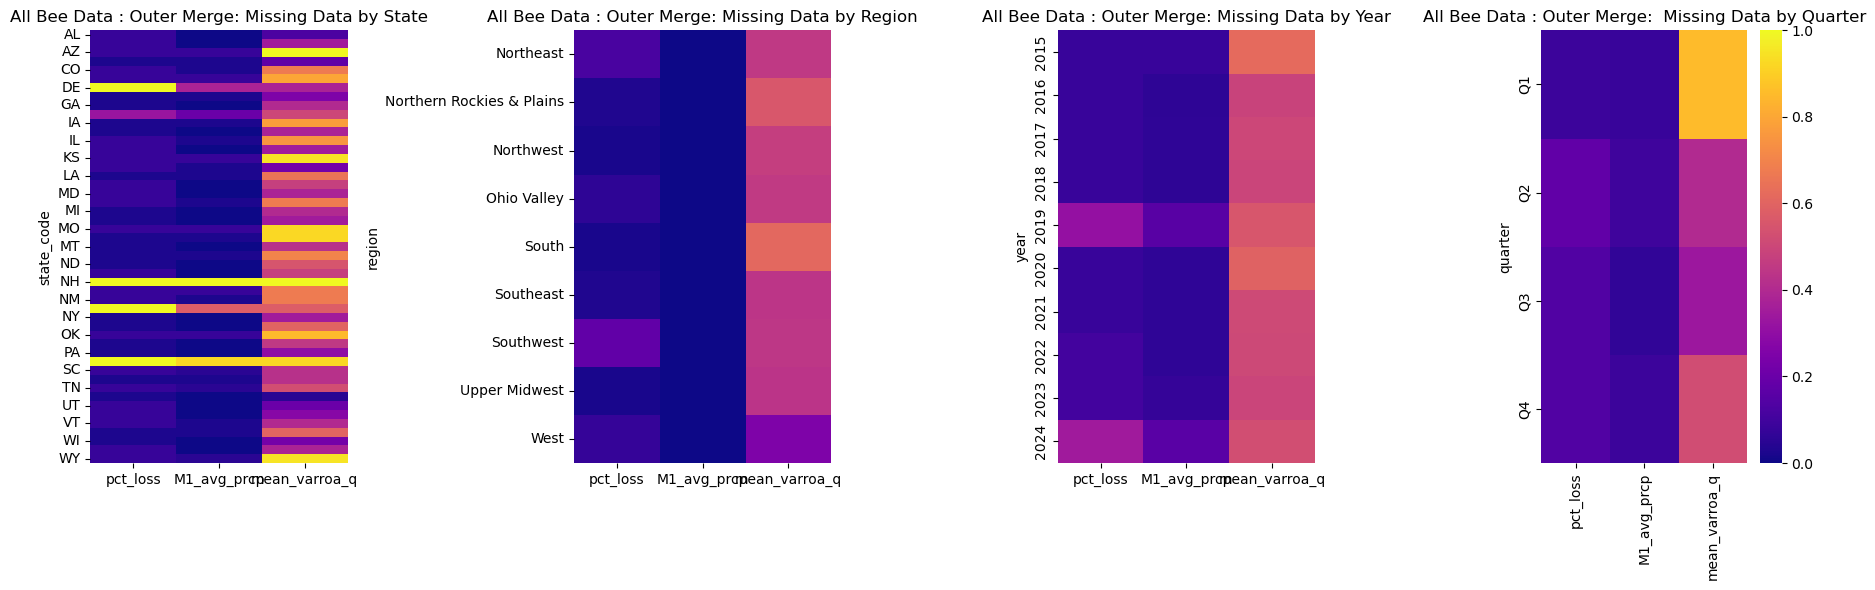

In [61]:
visualize_missing(bee_complete_df, expected, name='Complete Bee Data : Inner Merge')
visualize_missing(bee_nass_df, expected, name=' Bee Data on NASS')
visualize_missing(bee_aphis_df, expected, name=' Bee Data on APHIS')
visualize_missing(bee_all_df, expected, name='All Bee Data : Outer Merge')


There are a few pertinent observations: while there are some states missing completely from the APHIS and NASS data (like North Dakota), there are no regions for which the data is completely missing. 

When we restrict to the state/quarter/years present in both data sets, there are many Q1 data points missing. This could cause a problem later when we define a target variable based on the following quarter. 


We will proceed with: 

1. Only include all state/quarter/years for which there is data from both NASS and APHIS data sets. This is called bee_complete_df and will be saved as bee_combined_only_complete.csv 
2. Include all state/quarter/years from the NASS data set. Leave missing data as NaN. This is called bee_nass_df and will be saved as bee_combined_nass.csv. 
3. Including all state/quarter/years from NASS or APHIS. This is called bee_all_df and will be saved as bee_combined_all.csv. 

# Target: Risk of Colony Loss

We want to be able to use the data from one quarter to predict whether the next quarter will have a higher than average rate of colony collapse. We define the average risk to be the median risk over the past 5 years for a given state and quarter. We will use the NASS data where available and fill in with BIP data where needed. For year 2015-2019 for historic data, we will use an estimate of quarterly loss from the BIP seasonal loss data to fill in historic years. 


We will start by loading the BIP data so that we can fill in historic loss and gaps in the NASS reported percent loss. 

In [62]:
bip_df=pd.read_csv("../data/interim/quarterly_bip_df.csv")

In [63]:
bip_df['pct_loss'] = bip_df['loss_quarter']*100

In [ ]:
bip_df['region']=bip_df['state_code'].map(state_to_region)

In [64]:
bip_df.sample(5)

,state_code,year,quarter,loss_quarter,region,pct_loss
447,MD,2010,Q3,NaN,Northeast,NaN
218,DC,2009,Q2,NaN,NaN,NaN
1530,AL,2015,Q4,0.195875,Southeast,19.587529
2433,UT,2020,Q1,0.355051,Southwest,35.505097
580,OK,2010,Q4,NaN,South,NaN


In [65]:
bip_df = bip_df[bip_df['state_code'] != 'AK']
bip_df = bip_df[bip_df['state_code'] != 'DC']
bip_df = bip_df[bip_df['state_code'] != 'MSO']

In [76]:
bip_df.shape



(3072, 6)

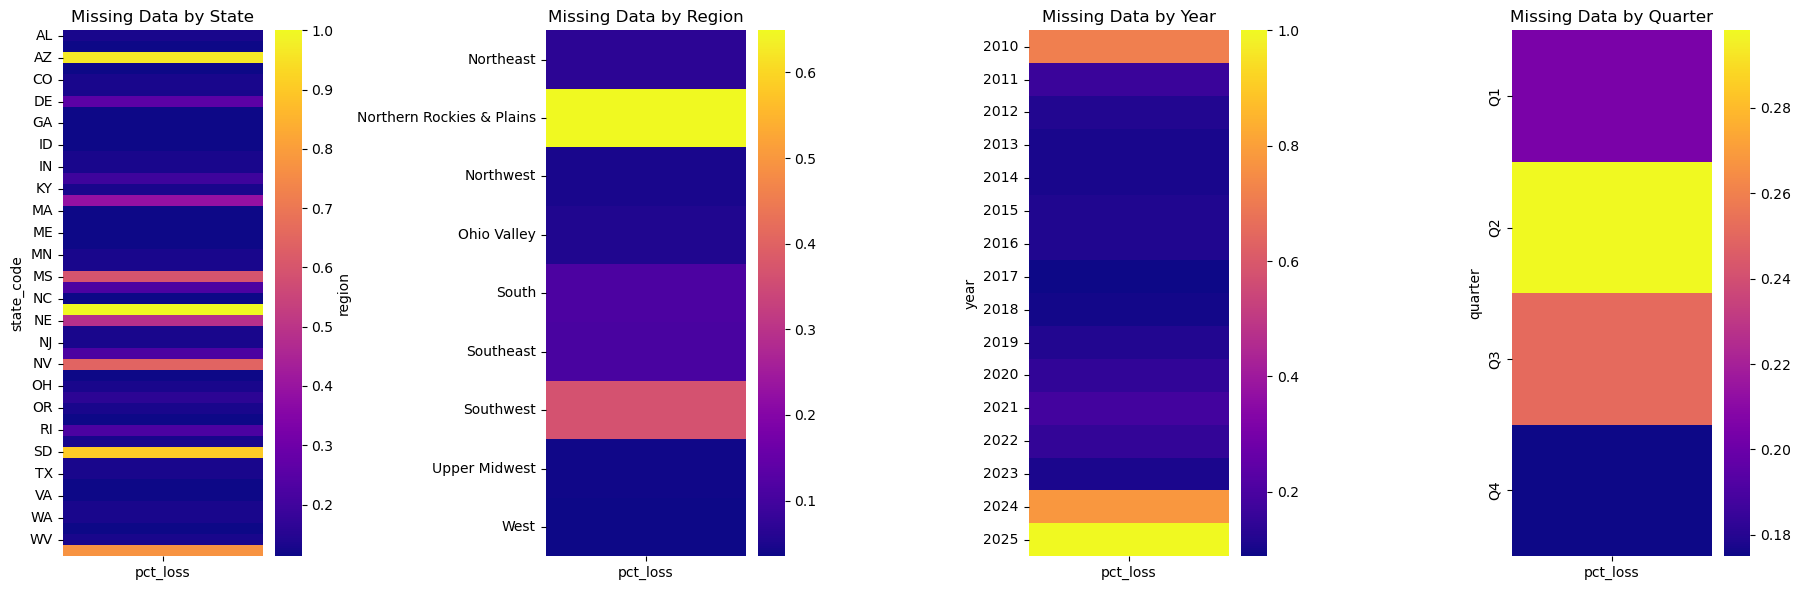

In [66]:
states = [state.abbr for state in us.states.STATES]
states = [s for s in states if s != "AK"]
states = [s for s in states if s != "HI"]
historic_years = range(2010, 2026)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

# Create a complete list of all possible months, years, and quarters
expected_historic = pd.DataFrame(product(states, historic_years, quarters),
                        columns=['state_code', 'year', 'quarter'])
# Limit to 2025 Q2
expected_historic = expected_historic[~((expected_historic['year'] == 2025) & (expected_historic['quarter'].isin(['Q3','Q4'])))]

merged_hist = expected_historic.merge(bip_df[['state_code', 'year', 'quarter', 'region', 'pct_loss']], on=['state_code', 'year', 'quarter'], how='left')

# Compute missing summaries
missing_state = merged_hist[['pct_loss']].isna().groupby(merged_hist['state_code']).mean()
missing_region = merged_hist[['pct_loss']].isna().groupby(merged_hist['region']).mean()
missing_year = merged_hist[['pct_loss']].isna().groupby(merged_hist['year']).mean()
missing_quarter = merged_hist[['pct_loss']].isna().groupby(merged_hist['quarter']).mean()

# Shared color scale
all_missing = pd.concat([missing_state, missing_year, missing_quarter])
vmin, vmax = all_missing.min().min(), all_missing.max().max()

# Plot
fig, axes = plt.subplots(1,4, figsize=(18, 6))
sns.heatmap(missing_state, ax=axes[0], cmap='plasma', cbar=True)
axes[0].set_title('Missing Data by State')

sns.heatmap(missing_region, ax=axes[1], cmap='plasma', cbar=True)
axes[1].set_title('Missing Data by Region')
    
sns.heatmap(missing_year, ax=axes[2], cmap='plasma', cbar=True)
axes[2].set_title('Missing Data by Year')
    
sns.heatmap(missing_quarter, ax=axes[3], cmap='plasma', cbar=True)
axes[3].set_title('Missing Data by Quarter')
    
plt.tight_layout()
plt.show()

In [100]:

# Define expected region/year/quarter grid
years = range(2010, 2025)
quarters = ['Q1', 'Q2', 'Q3', 'Q4']

expected_pairs = [
    (y, q)
    for y in years
    for q in quarters
    if not (y == 2024 and q in ['Q2', 'Q3', 'Q4'])
]

expected = pd.DataFrame(expected_pairs, columns=['year', 'quarter'])
regions = bip_df['region'].unique()

expected_full = pd.DataFrame(
    list(product(regions, expected['year'], expected['quarter'])),
    columns=['region', 'year', 'quarter']
)

# Identify region-year-quarter groups with at least one non-NaN pct_loss
has_valid = (
    bip_df.groupby(['region', 'year', 'quarter'])['pct_loss']
    .apply(lambda x: x.notna().any())     # True if at least one value is not NaN
    .reset_index(name='has_data')
)

has_valid = has_valid.drop_duplicates(subset=['region', 'year', 'quarter'])


# Merge with expected grid to find combos with no valid data
check = expected_full.merge(has_valid, on=['region', 'year', 'quarter'], how='left')
missing = check[check['has_data'] == False]  

missing= missing.drop_duplicates(subset=['region', 'year', 'quarter'])

print(f"Total region-year-quarter combos with all NaN or no data: {len(missing)}")
print(missing.sort_values(['region', 'year', 'quarter']).head(20))




Total region-year-quarter combos with all NaN or no data: 20
                          region  year quarter has_data
12997                  Northeast  2010      Q2    False
12998                  Northeast  2010      Q3    False
25992  Northern Rockies & Plains  2010      Q1    False
25993  Northern Rockies & Plains  2010      Q2    False
25994  Northern Rockies & Plains  2010      Q3    False
16246                  Northwest  2010      Q2    False
16247                  Northwest  2010      Q3    False
19494                Ohio Valley  2010      Q1    False
19495                Ohio Valley  2010      Q2    False
19496                Ohio Valley  2010      Q3    False
6499                       South  2010      Q2    False
6500                       South  2010      Q3    False
1                      Southeast  2010      Q2    False
2                      Southeast  2010      Q3    False
3250                   Southwest  2010      Q2    False
3251                   Southwest  2010     

8 of 9 regions are missing loss data for Q2 and Q3 of 2010. Therefore, we can use a regional average to fill in missing loss data (which begins in 2015). We will use a median over the known loss for all other states in the region. 

In [105]:
bip_df['pct_loss'] = bip_df['pct_loss'].fillna(
    bip_df.groupby(['region', 'year', 'quarter'])['pct_loss'].transform('median')
)


In [ ]:
# Start by filling all the NaN values in pct_loss with the regional mean for that year and quarter in both the BIP data and the NASS data. 
bee_all_df['pct_loss'] = bee_all_df['pct_loss'].fillna(
    bee_all_df.groupby(['region', 'year', 'quarter'])['pct_loss'].transform('mean')
) # Note: uses NASS loss data

bip_df['pct_loss'] = bip_df['pct_loss'].fillna(
    bip_df.groupby(['region', 'year', 'quarter'])['pct_loss'].transform('mean')
)

In [ ]:
print(bee_all_df['pct_loss'].isna().any())
print(bee_complete_df['pct_loss'].isna().any())
print(bee_nass_df['pct_loss'].isna().any())
print(bip_df['pct_loss'].isna().any())

In [107]:
bee_all_df[bee_all_df['pct_loss'].isna()]

,year,quarter,pct_loss,pct_disease,pct_other,pct_pesticides,pct_pests_nomites,pct_unknown,pct_varroa,state_code,...,Q_tmin_avg,Num_Frost_Days,M1_avg_tvol,M2_avg_tvol,M3_avg_tvol,M1_max_tvol,M2_max_tvol,M3_max_tvol,Q_tvol_avg,Num_high_vol_days
231,2016,Q2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE,...,0.709912,0.053763,0.499274,0.500249,0.588876,0.153009,0.243757,0.335344,0.346565,0.042857
277,2016,Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE,...,0.906870,0.010753,0.360234,0.562431,0.512479,0.377721,0.475030,0.202654,0.283647,0.000000
301,2016,Q3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NV,...,0.722154,0.010753,0.896134,0.920411,0.895781,0.971831,0.953627,0.743064,0.908829,0.800000
324,2016,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,DE,...,0.544831,0.290323,0.413637,0.605151,0.512493,0.129962,0.338288,0.313631,0.328123,0.014286
348,2016,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NV,...,0.421136,0.494624,0.641929,0.707525,0.623257,0.475672,0.372176,0.525935,0.539541,0.071429
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1786,2024,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NM,...,0.457363,0.591398,0.891934,0.789318,0.913432,0.620999,0.467301,0.803378,0.844795,0.600000
1791,2024,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RI,...,0.487605,0.376344,0.507529,0.551836,0.487373,0.468630,0.247919,0.295537,0.326038,0.014286
1794,2024,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UT,...,0.414503,0.677419,0.680695,0.632249,0.639517,0.377721,0.425089,0.507238,0.524215,0.071429
1795,2024,Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,VA,...,0.526542,0.236559,0.622126,0.622740,0.558923,0.226633,0.275862,0.269602,0.451171,0.071429


In [ ]:

def build_combined_loss_df(
    nass_df, 
    bip_df, 
    dfs_to_update, 
    years=range(2010, 2026), 
    quarters=('Q1', 'Q2', 'Q3', 'Q4')
):
    """
    Build a combined loss dataset using nass_df and bip_df, then
    apply it to a list of dataframes (dfs_to_update) by adding/filling pct_loss.

    Steps:
      1. Create a full grid of all (state, year, quarter) combinations for 2010–2025 Q2.
      2. Merge nass_df and bip_df (nass preferred, bip fills missing).
      3. Fill remaining NaN with regional means from nass_df.
      4. Return both the combined dataset and a list of updated dataframes.
    """

    all_states = sorted([state.abbr for state in us.states.STATES])

    # Create full grid
    full_index = pd.DataFrame(itertools.product(all_states, years, quarters),
                              columns=['state_code','year','quarter'])
    # Limit to 2025 Q2
    full_index = full_index[~((full_index['year'] == 2025) & (full_index['quarter'].isin(['Q3','Q4'])))]

    # Merge nass_df and bip_df
    key_cols = ['state_code','year','quarter','region']
    
    nass_sub = nass_df[key_cols + ['pct_loss']].drop_duplicates(subset=key_cols)
    bip_sub = bip_df[key_cols + ['pct_loss']].drop_duplicates(subset=key_cols)

    combined = full_index.merge(bip_sub, on=['state_code','year','quarter'], how='left', suffixes=('', '_bip'))
    combined = combined.merge(nass_sub, on=['state_code','year','quarter'], how='left', suffixes=('_bip','_nass'))

    # Prefer nass_df pct_loss, fill with bip_df pct_loss
    combined['pct_loss'] = combined['pct_loss_nass'].combine_first(combined['pct_loss_bip'])
    combined['region'] = combined['region_nass'].combine_first(combined['region_bip'])

    # Compute regional means from nass_df
    regional_means = (
        nass_df.groupby(['region','year','quarter'])['pct_loss']
        .mean()
        .reset_index()
        .rename(columns={'pct_loss':'regional_mean'})
    )

    # Merge regional means and fill missing pct_loss
    combined = combined.merge(regional_means, on=['region','year','quarter'], how='left')
    combined['pct_loss'] = combined['pct_loss'].fillna(combined['regional_mean'])
    combined = combined[['state_code','year','quarter','region','pct_loss']]

    # Apply to each dataframe in dfs_to_update
    updated_dfs = []
    for df in dfs_to_update:
        merged = df.merge(
            combined, 
            on=['state_code','year','quarter','region'], 
            how='left', 
            suffixes=('', '_combined')
        )
        # Fill pct_loss if missing in the input df
        merged['pct_loss'] = merged['pct_loss'].combine_first(merged['pct_loss_combined'])
        merged = merged.drop(columns=['pct_loss_combined'])
        updated_dfs.append(merged)

    return combined, updated_dfs


In [ ]:
combined_loss_df, [bee_all_df] = build_combined_loss_df(
    nass_df=nass_df,
    bip_df=bip_df,
    dfs_to_update=[bee_all_df]
)



In [ ]:
combined_loss_df.sample(50)

In [ ]:
def add_5yr_median_combined(df, T=5):
    """
    Adds a column '5yr_median' to combined_loss_df that contains the rolling
    median of the previous T years, grouped by state and quarter.
    Works even if there are duplicate years per state/quarter.
    """
    df = df.copy()
    
    # Sort by state, quarter, year
    df = df.sort_values(['state_code','quarter','year']).reset_index(drop=True)
    
    # Initialize the new column
    df['5yr_median'] = pd.NA
    
    # Compute rolling median per state & quarter
    for (state, quarter), group in df.groupby(['state_code','quarter'], sort=False):
        # Sort by year to ensure correct rolling
        group_sorted = group.sort_values('year')
        # Rolling median of past T years, shift by 1 to exclude current year
        median_vals = group_sorted['pct_loss'].rolling(window=T, min_periods=1).median().shift(1)
        # Assign back to original df
        df.loc[group_sorted.index, '5yr_median'] = median_vals
        
    return df


In [ ]:
combined_loss_df = add_5yr_median_combined(combined_loss_df, T=5)


combined_loss_df.head(10)


In [ ]:

def add_next_quarter_flag_combined(df, combined_loss_df, pct_col='pct_loss', median_col='5yr_median'):
    """
    Adds a binary flag column to df indicating whether the pct_loss in the 
    next quarter exceeds the 5-year median in combined_loss_df.
    
    Parameters:
        df: DataFrame with ['state_code','year','quarter',pct_col]
        combined_loss_df: DataFrame with ['state_code','year','quarter',median_col]
        pct_col: column in df to compare
        median_col: column in combined_loss_df to use for comparison
    Returns:
        df with new column 'pct_loss_above_next_median'
    """
    df = df.copy()
    
    # Map quarters to numeric order
    quarter_order = ['Q1','Q2','Q3','Q4']
    df['quarter_num'] = df['quarter'].map({q: i for i, q in enumerate(quarter_order, start=1)})

    # Prepare combined_loss_df for fast lookup
    combined_lookup = combined_loss_df.set_index(['state_code','year','quarter'])

    def compute_flag(group):
        group = group.sort_values(['year', 'quarter_num']).copy()
        flag = pd.Series(index=group.index, dtype='object')  # allow NA

        for idx, row in group.iterrows():
            y, q = row['year'], row['quarter_num']
            state = row['state_code']

            # Determine next quarter
            if q < 4:
                next_y, next_q_num = y, q + 1
            else:
                next_y, next_q_num = y + 1, 1

            next_q = quarter_order[next_q_num - 1]

            # Try to get next quarter's pct_loss and 5yr_median from combined_loss_df
            try:
                next_row = combined_lookup.loc[(state, next_y, next_q)]
                next_pct = next_row[pct_col] if pct_col in next_row else pd.NA
                next_median = next_row[median_col] if median_col in next_row else pd.NA
            except KeyError:
                next_pct = pd.NA
                next_median = pd.NA

            if pd.isna(next_pct) or pd.isna(next_median):
                flag[idx] = pd.NA
            else:
                flag[idx] = int(next_pct > next_median)

        group['pct_loss_above_next_median'] = flag
        return group

    df = df.groupby('state_code', group_keys=False).apply(compute_flag)
    df = df.drop(columns=['quarter_num'])
    return df


In [ ]:
bee_all_df = add_next_quarter_flag_combined(
    bee_all_df,
    combined_loss_df,
    pct_col='pct_loss',
    median_col='5yr_median'
)

bee_complete_df = add_next_quarter_flag_combined(
    bee_complete_df,
    combined_loss_df,
    pct_col='pct_loss',
    median_col='5yr_median'
)

bee_nass_df = add_next_quarter_flag_combined(
    bee_nass_df,
    combined_loss_df,
    pct_col='pct_loss',
    median_col='5yr_median'
)




In [ ]:

# def add_rolling_median_loss(df, combined_loss_df, T=5):
#     """
#     Adds a column '5yr_median_loss' to df using pct_loss from combined_loss_df.
    
#     Parameters:
#         df: DataFrame to enrich (must have ['state_code','year','quarter'])
#         combined_loss_df: DataFrame with ['state_code','year','quarter','pct_loss']
#         T: Number of years to look back for the rolling median
#     Returns:
#         df with a new column '5yr_median_loss'
#     """
#     df = df.copy()
    
#     def get_rolling_median(row):
#         state = row['state_code']
#         year = row['year']
#         quarter = row['quarter']
#         years_needed = list(range(year - T, year))
        
#         vals = combined_loss_df.loc[
#             (combined_loss_df['state_code'] == state) &
#             (combined_loss_df['quarter'] == quarter) &
#             (combined_loss_df['year'].isin(years_needed)),
#             'pct_loss'
#         ]
#         return vals.median() if not vals.empty else pd.NA
    
#     # Apply row-wise
#     df['5yr_median_loss'] = df.apply(get_rolling_median, axis=1)
    
#     return df


In [ ]:
# bee_all_df = add_rolling_median_loss(bee_all_df, combined_loss_df)
# bee_complete_df = add_rolling_median_loss(bee_complete_df, combined_loss_df)
# bee_nass_df = add_rolling_median_loss(bee_nass_df, combined_loss_df)

In [ ]:
bee_nass_df.sample(10)

Now that the median loss is computed. We will finally add the target column: 'pct_loss_above_next_median' which will check if the percent loss for the following quarter loss is higher than the 5 year median for that quarter. If the data is not available for the next quarter, we will leave the entry as NaN

In [ ]:
# def add_next_quarter_flag(df, pct_col='pct_loss', median_col='5yr_median_loss'):
#     df = df.copy()
    
#     # Map quarters to numeric order
#     quarter_order = ['Q1','Q2','Q3','Q4']
#     df['quarter_num'] = df['quarter'].map({q: i for i, q in enumerate(quarter_order, start=1)})

#     def compute_flag(group):
#         group = group.sort_values(['year', 'quarter_num']).copy()
        
#         flag = pd.Series(index=group.index, dtype='object')  # use object dtype to allow NA

#         for idx, row in group.iterrows():
#             y, q = row['year'], row['quarter_num']
#             # Determine next quarter
#             if q < 4:
#                 next_y, next_q = y, q + 1
#             else:
#                 next_y, next_q = y + 1, 1

#             # Check if next quarter exists
#             next_row = group[(group['year'] == next_y) & (group['quarter_num'] == next_q)]
#             if next_row.empty:
#                 flag[idx] = pd.NA
#             else:
#                 next_pct = next_row[pct_col].values[0]
#                 next_median = next_row[median_col].values[0]
#                 if pd.isna(next_pct) or pd.isna(next_median):
#                     flag[idx] = pd.NA
#                 else:
#                     flag[idx] = int(next_pct > next_median)
        
#         group['pct_loss_above_next_median'] = flag
#         return group

#     df = df.groupby('state_code', group_keys=False).apply(compute_flag)
    
#     df = df.drop(columns=['quarter_num'])
#     return df


In [ ]:
bee_all_df = add_next_quarter_flag(bee_all_df)
bee_complete_df = add_next_quarter_flag(bee_complete_df)
bee_nass_df = add_next_quarter_flag(bee_complete_df)


In [ ]:
bee_all_df.sample(5)


In [ ]:
print( bee_all_df['pct_loss_above_next_median'].value_counts(dropna=True))
bee_all_df.shape

In [ ]:
print(bee_complete_df['pct_loss_above_next_median'].value_counts(dropna=True))
bee_complete_df.shape

In [ ]:
print(bee_nass_df['pct_loss_above_next_median'].value_counts(dropna=True))
bee_nass_df.shape

In [ ]:
bee_all_df.to_csv("../data/processed/bee_combined_all.csv")
bee_complete_df.to_csv("../data/processed/bee_combined_only_complete.csv")
bee_nass_df.to_csv("../data/processed/bee_combined_nass.csv")
